<a href="https://colab.research.google.com/github/Soco-Roman/GISLatam_2026/blob/main/Exercise_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Estimation of Cycling incidents in CDMX

This notebook performs a spatial analysis of bicycle incidents in Mexico City (CDMX) in relation to its cycling infrastructure. It covers data loading, reprojection, filtering, buffer analysis, spatial joining, statistical calculation, and high-resolution visualizations.

In [3]:
# Install necessary libraries
!pip install geopandas contextily matplotlib matplotlib_scalebar

Loading data...
Data loaded.
Reprojecting data to EPSG:3857...
Data reprojected.
Filtering data...
Data filtered.
Generating 5-meter buffer around active cycling infrastructure...
Buffer generated.
Performing spatial join to identify incidents within buffer...
Spatial join complete.
Calculating statistics...
Total bicycle incidents: 105
Incidents within 5m buffer of cycling infrastructure: 12 (11.43%)
Incidents outside 5m buffer of cycling infrastructure: 93 (88.57%)
Statistics calculated.
Generating pie chart...


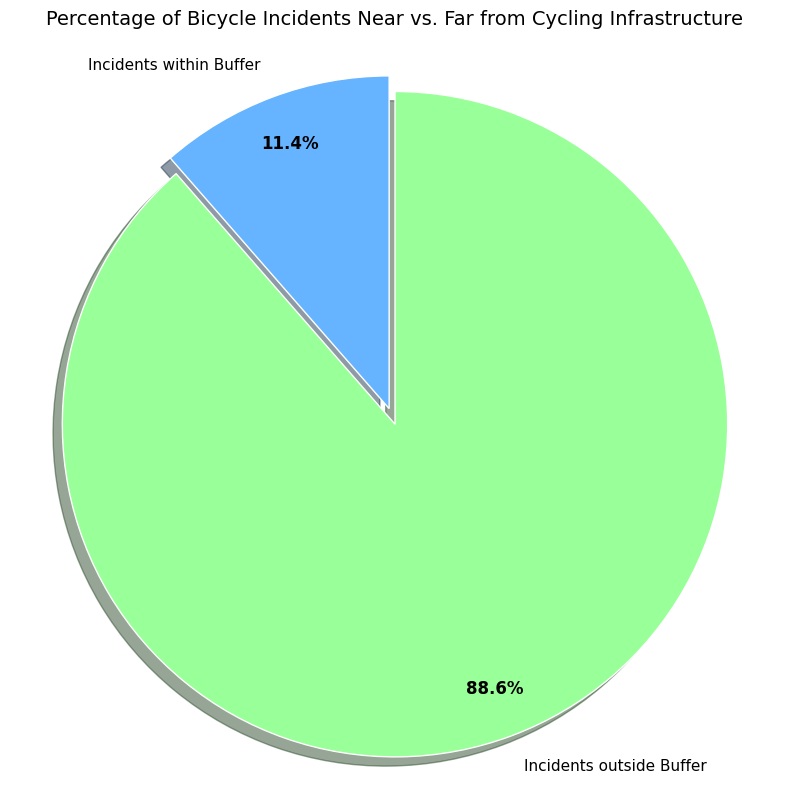

Pie chart saved as 'cycle_inicent_stats_pie.png'.
Constructing map...


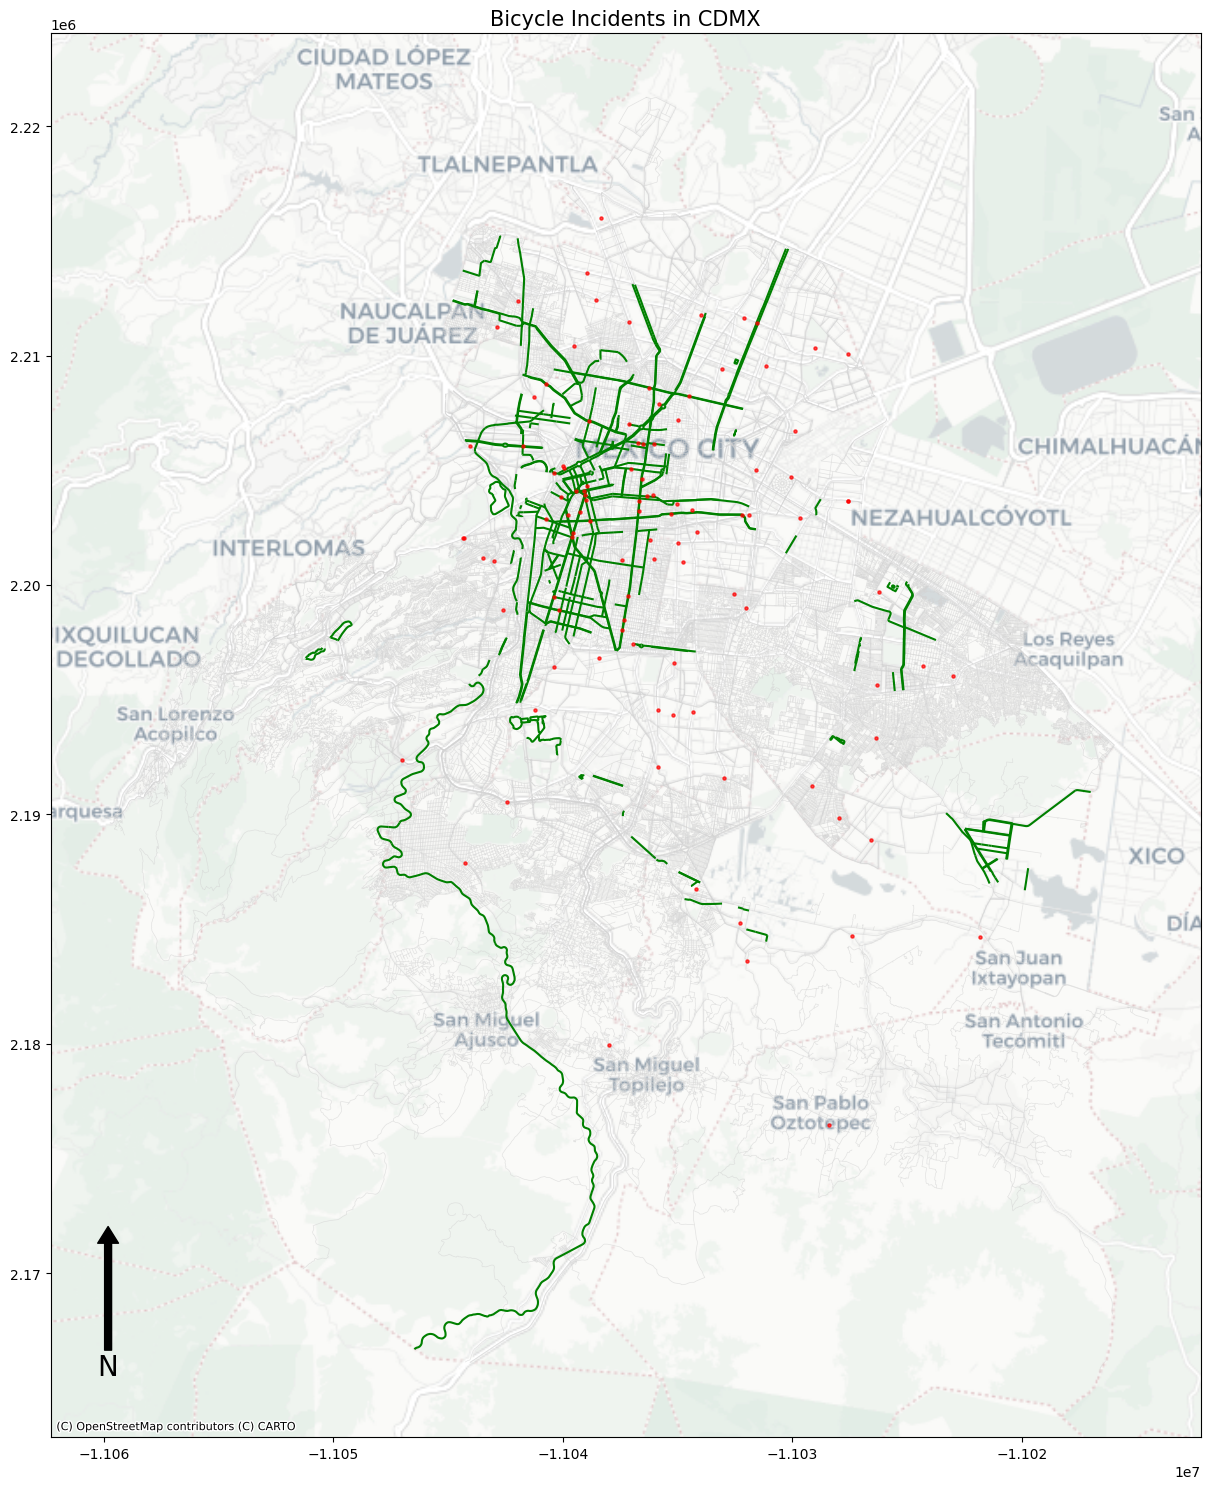

Map saved as 'cdmx_bicycle_incidents_map.png'.


In [6]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as cx
from matplotlib_scalebar.scalebar import ScaleBar # Not explicitly asked for scale bar but useful in maps.
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
import numpy as np

# 1. Load Data
print("Loading data...")
infra_ciclista_gdf = gpd.read_file('/content/infra_ciclista.geojson')
vialidades_cdmx_gdf = gpd.read_file('/content/vialidades_cdmx.geojson')
atus_cdmx_gdf = gpd.read_file('/content/atus_cdmx.geojson')

print("Data loaded.")

# 2. Reprojection to Web Mercator (EPSG:3857)
print("Reprojecting data to EPSG:3857...")
infra_ciclista_gdf = infra_ciclista_gdf.to_crs(epsg=3857)
vialidades_cdmx_gdf = vialidades_cdmx_gdf.to_crs(epsg=3857)
atus_cdmx_gdf = atus_cdmx_gdf.to_crs(epsg=3857)

print("Data reprojected.")

# 3. Data Filtering
print("Filtering data...")
# Filter cycling infrastructure
infra_ciclista_active_gdf = infra_ciclista_gdf[infra_ciclista_gdf['ESTADO'] != 'Fuera de servicio']

# Filter bicycle accidents
siniestros_ciclistas = atus_cdmx_gdf[atus_cdmx_gdf['BICICLETA'] != 0]

print("Data filtered.")

# 4. Buffer generation (5-meter buffer)
print("Generating 5-meter buffer around active cycling infrastructure...")
infra_ciclista_buffer = infra_ciclista_active_gdf.buffer(5)

print("Buffer generated.")

# Convert buffer to GeoDataFrame for spatial operations
infra_ciclista_buffer_gdf = gpd.GeoDataFrame(geometry=infra_ciclista_buffer, crs=3857)

# 5. Spatial join
print("Performing spatial join to identify incidents within buffer...")
# Create a single geometry representing the combined buffer
combined_buffer_geometry = infra_ciclista_buffer_gdf.union_all() # Using union_all() to avoid DeprecationWarning

# Wrap the combined geometry in a GeoDataFrame and assign the CRS
# This ensures it behaves like a GeoSpatial object with CRS information for sjoin
combined_buffer_final_gdf = gpd.GeoDataFrame(geometry=[combined_buffer_geometry], crs=infra_ciclista_buffer_gdf.crs)

# Use 'intersects' predicate to find incidents within the buffer
incidents_in_buffer = gpd.sjoin(
    siniestros_ciclistas,
    combined_buffer_final_gdf,
    how='inner',
    predicate='intersects'
)

# Get incidents outside the buffer
incidents_outside_buffer = siniestros_ciclistas[~siniestros_ciclistas.index.isin(incidents_in_buffer.index)]

print("Spatial join complete.")

# 6. Statistical Calculation
print("Calculating statistics...")
total_incidents = len(siniestros_ciclistas)
incidents_in_buffer_count = len(incidents_in_buffer)
incidents_outside_buffer_count = len(incidents_outside_buffer)

percentage_in_buffer = (incidents_in_buffer_count / total_incidents) * 100
percentage_outside_buffer = (incidents_outside_buffer_count / total_incidents) * 100

print(f"Total bicycle incidents: {total_incidents}")
print(f"Incidents within 5m buffer of cycling infrastructure: {incidents_in_buffer_count} ({percentage_in_buffer:.2f}%)")
print(f"Incidents outside 5m buffer of cycling infrastructure: {incidents_outside_buffer_count} ({percentage_outside_buffer:.2f}%)")
print("Statistics calculated.")

# 7. Chart visualization and export (Pie Chart)
print("Generating pie chart...")
labels = ['Incidents within Buffer', 'Incidents outside Buffer']
sizes = [percentage_in_buffer, percentage_outside_buffer]
colors = ['#66b3ff', '#99ff99'] # Distinct colors
explode = (0.05, 0)  # Explode the first slice for emphasis

fig1, ax1 = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax1.pie(sizes, explode=explode, labels=labels, colors=colors,
                                  autopct='%1.1f%%', shadow=True, startangle=90,
                                  pctdistance=0.85, wedgeprops=dict(edgecolor='w'))

# Set font properties for percentage labels
plt.setp(autotexts, size=12, weight="bold")
plt.setp(texts, size=11)

ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
ax1.set_title('Percentage of Bicycle Incidents Near vs. Far from Cycling Infrastructure',
              fontsize=14, pad=20)

plt.tight_layout()
plt.savefig('cycle_inicent_stats_pie.png', dpi=300, bbox_inches='tight')
plt.show()
print("Pie chart saved as 'cycle_inicent_stats_pie.png'.")

# 8. Map construction and layers
print("Constructing map...")
fig2, ax2 = plt.subplots(1, 1, figsize=(15, 15))

# Plot vialidades_cdmx as a light grey background
vialidades_cdmx_gdf.plot(ax=ax2, color='lightgrey', linewidth=0.5, alpha=0.6, zorder=1)

# Plot active cycling infrastructure as green lines
infra_ciclista_active_gdf.plot(ax=ax2, color='green', linewidth=1.5, zorder=2)

# Plot bicycle incidents as red points
siniestros_ciclistas.plot(ax=ax2, color='red', marker='o', markersize=5, alpha=0.7, zorder=3)

# 9. Basemap: Add CartoDB Positron
cx.add_basemap(ax2, crs=infra_ciclista_active_gdf.crs.to_string(), source=cx.providers.CartoDB.Positron)

# 10. Map elements: Add a North arrow
# Custom North arrow
x, y, arrow_length = 0.05, 0.15, 0.1 # Position and size relative to plot
ax2.annotate('N', xy=(x, y), xytext=(x, y - arrow_length),
             arrowprops=dict(facecolor='black', width=5, headwidth=15),
             ha='center', va='center', fontsize=20, color='black',
             xycoords=ax2.transAxes)

# 11. Formatting
ax2.set_title('Bicycle Incidents in CDMX', fontsize=15)
ax2.set_axis_on() # Ensure axes are explicitly on

plt.tight_layout()
plt.savefig('cdmx_bicycle_incidents_map.png', dpi=300, bbox_inches='tight')
plt.show()
print("Map saved as 'cdmx_bicycle_incidents_map.png'.")